# Prognozowanie popytu na rowery miejskie w Londynie z wykorzystaniem modeli regresyjnych

## 1. Wczytanie danych

Dataset powstał z trzech zbiorów danych połączonych w środowisku Google BigQuery w jedną tabelę za pomocą języka SQL
1. Publiczne dane o systemie rowerów miejskich w Londynie dostępne w [BigQuery](https://console.cloud.google.com/bigquery?ws=!1m4!1m3!3m2!1sbigquery-public-data!2slondon_bicycles)
2. Dane o bezpieczeństwie rowerzystów w Londynie dostępne na [Kaggle](https://www.kaggle.com/datasets/dtuthill/london-cycling-safety)
3. Dane o pogodzie w Londynie pobrane ze strony [Visual Crossing](https://www.visualcrossing.com/weather-query-builder/#)

Przygotowany dataset obejmuje dane z lat 2016-2018

In [1]:
# Załadowanie potrzebnych bibliotek
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date

In [ ]:
# Wczytanie zboru danych
df = pd.read_csv('data/london_bikes.csv.zip')

# Sprawdzenie pierwszych pięciu wierszy zbioru danych
df.head()

,date,station_id,station_name,is_holiday,trip_count,fatal_acc,serious_acc,slight_acc,num_acc,temp1,temp2,hum,wind_speed,weather_type,weather_code
0,2016-01-01,NaN,NaN,1,716,0,0,0,0,5.9,3.6,84.7,24.7,rain,4
1,2016-01-01,1.0,"River Street , Clerkenwell",1,7,0,0,0,0,5.9,3.6,84.7,24.7,rain,4
2,2016-01-01,2.0,"Phillimore Gardens, Kensington",1,10,0,0,0,0,5.9,3.6,84.7,24.7,rain,4
3,2016-01-01,4.0,"St. Chad's Street, King's Cross",1,3,0,0,0,0,5.9,3.6,84.7,24.7,rain,4
4,2016-01-01,5.0,"Sedding Street, Sloane Square",1,16,0,0,0,0,5.9,3.6,84.7,24.7,rain,4


Oto zestaw danych o systemie rowerów miejskich w Londynie, zawiera on następujące kolumny:
* __date__: data wypożyczenia
* __station_id__: unikalne id stacji wypożyczeń
* __station_name__: nazwa stacji wypożyczeń
* __is_holiday__: informacja, czy w danym dniu jest dzień wolny od pracy ze względu na święto (eng. bank holiday)
* __trip_count__: suma wypożyczeń w danym dniu, na danej stacji
* __fatal_acc__: suma wypadków śmiertelnych z udziałem rowerzysty w danym dniu, w promieniu 500 metrów od danej stacji
* __serious_acc__: suma poważnych wypadków z udziałem rowerzysty w danym dniu, w promieniu 500 metrów od danej stacji
* __slight_acc__: suma kolizji z udziałem rowerzysty w danym dniu, w promieniu 500 metrów od danej stacji
* __num_acc__: suma wszystkch wypadków/kolizji w danym dniu, w promieniu 500 metrów od danej stacji
* __temp1__: średnia dobowa temperatura w danym dniu w C
* __temp2__: średnia dobowa temperatura odczuwalna w danym dniu w C
* __hum__: średnia wilgotność powietrza w danym dniu w %
* __wind_speed__: średnia dobowa prędkość wiatru w km/h
* __weather_type__: uogólniona informacja o pogodzie w danym dniu
* __weather_code__: zakodowana uogólniona informacja o pogodzie w danym dniu (1 -słonecznie, 2 - częściowe zachmurzenie, 3 - pełne zachmurzenie, 4 - deszcz, 5- śnieg)

## 2. Przygotowanie danych do dalszej analizy

### 2.1 Informacje o kolumnach i wierszach

In [3]:
# Wyświetlenie podstawowych informacji o zbiorze danych
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785518 entries, 0 to 785517
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          785518 non-null  object 
 1   station_id    784422 non-null  float64
 2   station_name  784422 non-null  object 
 3   is_holiday    785518 non-null  int64  
 4   trip_count    785518 non-null  int64  
 5   fatal_acc     785518 non-null  int64  
 6   serious_acc   785518 non-null  int64  
 7   slight_acc    785518 non-null  int64  
 8   num_acc       785518 non-null  int64  
 9   temp1         785518 non-null  float64
 10  temp2         785518 non-null  float64
 11  hum           785518 non-null  float64
 12  wind_speed    785518 non-null  float64
 13  weather_type  785518 non-null  object 
 14  weather_code  785518 non-null  int64  
dtypes: float64(5), int64(7), object(3)
memory usage: 89.9+ MB


In [4]:
# Sprawdzenie liczby kolumn i wierszy
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 785518
Number of columns: 15


### 2.2 Braki danych

In [5]:
# Sprawdzenie, czy w zbiorze danych są brakujące wartości
df.isna().sum()

date               0
station_id      1096
station_name    1096
is_holiday         0
trip_count         0
fatal_acc          0
serious_acc        0
slight_acc         0
num_acc            0
temp1              0
temp2              0
hum                0
wind_speed         0
weather_type       0
weather_code       0
dtype: int64

In [6]:
# Ze względu na małą liczbę brakujących wartości w stosunku do całego zbioru danych, usuniemy je
df.dropna(inplace=True)

In [7]:
# Ponowne spradzenie, czy w zborze danych są brakujące wartości
df.isna().sum()

date            0
station_id      0
station_name    0
is_holiday      0
trip_count      0
fatal_acc       0
serious_acc     0
slight_acc      0
num_acc         0
temp1           0
temp2           0
hum             0
wind_speed      0
weather_type    0
weather_code    0
dtype: int64

### 2.3 Zduplikowane wiersze

In [8]:
# Sprawdzenie czy w zbiorze danych są duplkaty
duplicates = df.duplicated().sum()
print(f'Liczba duplikatów: {duplicates}')

Liczba duplikatów: 0


In [9]:
# Sprawdzenie typów zmiennych w zbiorze
print('\nTypy zmiennych:\n', df.dtypes)


Typy zmiennych:
 date             object
station_id      float64
station_name     object
is_holiday        int64
trip_count        int64
fatal_acc         int64
serious_acc       int64
slight_acc        int64
num_acc           int64
temp1           float64
temp2           float64
hum             float64
wind_speed      float64
weather_type     object
weather_code      int64
dtype: object


### 2.3 Inżynieria cech

In [10]:
# Konwersja kolumny 'is_holiday' na typ boolean
df.is_holiday = df.is_holiday.astype('bool')


In [11]:
# Rozdzielenie daty na poszczególne komponenty
df['datet'] = pd.to_datetime(df.date, format = '%Y-%m-%d')
df['year'] = df.datet.dt.year
df['month'] = df.datet.dt.month
df['day'] = df.datet.dt.day
df['weekday'] = df.datet.dt.dayofweek

In [12]:
# Stworzenie nowej kolumny 'is_weekend' wskazującej, czy dany dzień to weekend
df['is_weekend'] = df.datet.dt.dayofweek >= 5

In [13]:
# Stworzenie nowej kolumny 'season' wskazującej na porę roku
def get_season(month):
    if month in [12, 1, 2]:
        return 1 #coding for winter
    elif month in [3, 4, 5]:
        return 2  #coding for spring
    elif month in [6, 7, 9]:
        return 3 #coding for summer
    else:
        return 4 #coding for autumn
    
df['season'] = df.datet.dt.month.apply(get_season)

Kolumna 'season':
* __1__ - zima
* __2__ - wiosna
* __3__ - lato
* __4__ - jesień

In [14]:
# Sprawdzenie typów zmiennych w zbiorze 
print('\nData types:\n', df.dtypes)


Data types:
 date                    object
station_id             float64
station_name            object
is_holiday                bool
trip_count               int64
fatal_acc                int64
serious_acc              int64
slight_acc               int64
num_acc                  int64
temp1                  float64
temp2                  float64
hum                    float64
wind_speed             float64
weather_type            object
weather_code             int64
datet           datetime64[ns]
year                     int32
month                    int32
day                      int32
weekday                  int32
is_weekend                bool
season                   int64
dtype: object


## 3. Eksploracyjna analiza danych

In [15]:
# Określenie typów zmiennych dla każdej kolumny
categorical_features = ['weekday', 'is_holiday', 'weather_code', 'is_weekend', 'season']
numerical_features = ['trip_count', 'fatal_acc', 'serious_acc', 'slight_acc', 'num_acc', 'temp1', 'temp2', 'hum', 'wind_speed']

### 3.1 Zmienne numeryczne

In [16]:
# Wyświetlenie statystyk opisowych dla zmiennych numerycznych
df[numerical_features].describe()

,trip_count,fatal_acc,serious_acc,slight_acc,num_acc,temp1,temp2,hum,wind_speed
count,784422.000000,784422.000000,784422.000000,784422.000000,784422.000000,784422.000000,784422.000000,784422.000000,784422.000000
mean,36.835787,0.005897,0.299042,1.622704,1.927644,12.243218,11.385072,75.045485,20.703807
std,33.843973,0.619292,5.047158,11.244247,12.408619,5.645112,6.605506,10.182179,7.450950
min,1.000000,0.000000,0.000000,0.000000,0.000000,-3.200000,-8.500000,39.600000,4.700000
25%,17.000000,0.000000,0.000000,0.000000,0.000000,7.700000,5.800000,67.800000,15.400000
50%,29.000000,0.000000,0.000000,0.000000,0.000000,11.900000,11.700000,75.500000,19.900000
75%,46.000000,0.000000,0.000000,0.000000,0.000000,16.800000,16.800000,82.700000,24.900000
max,895.000000,161.000000,821.000000,744.000000,821.000000,26.800000,26.600000,99.400000,59.000000


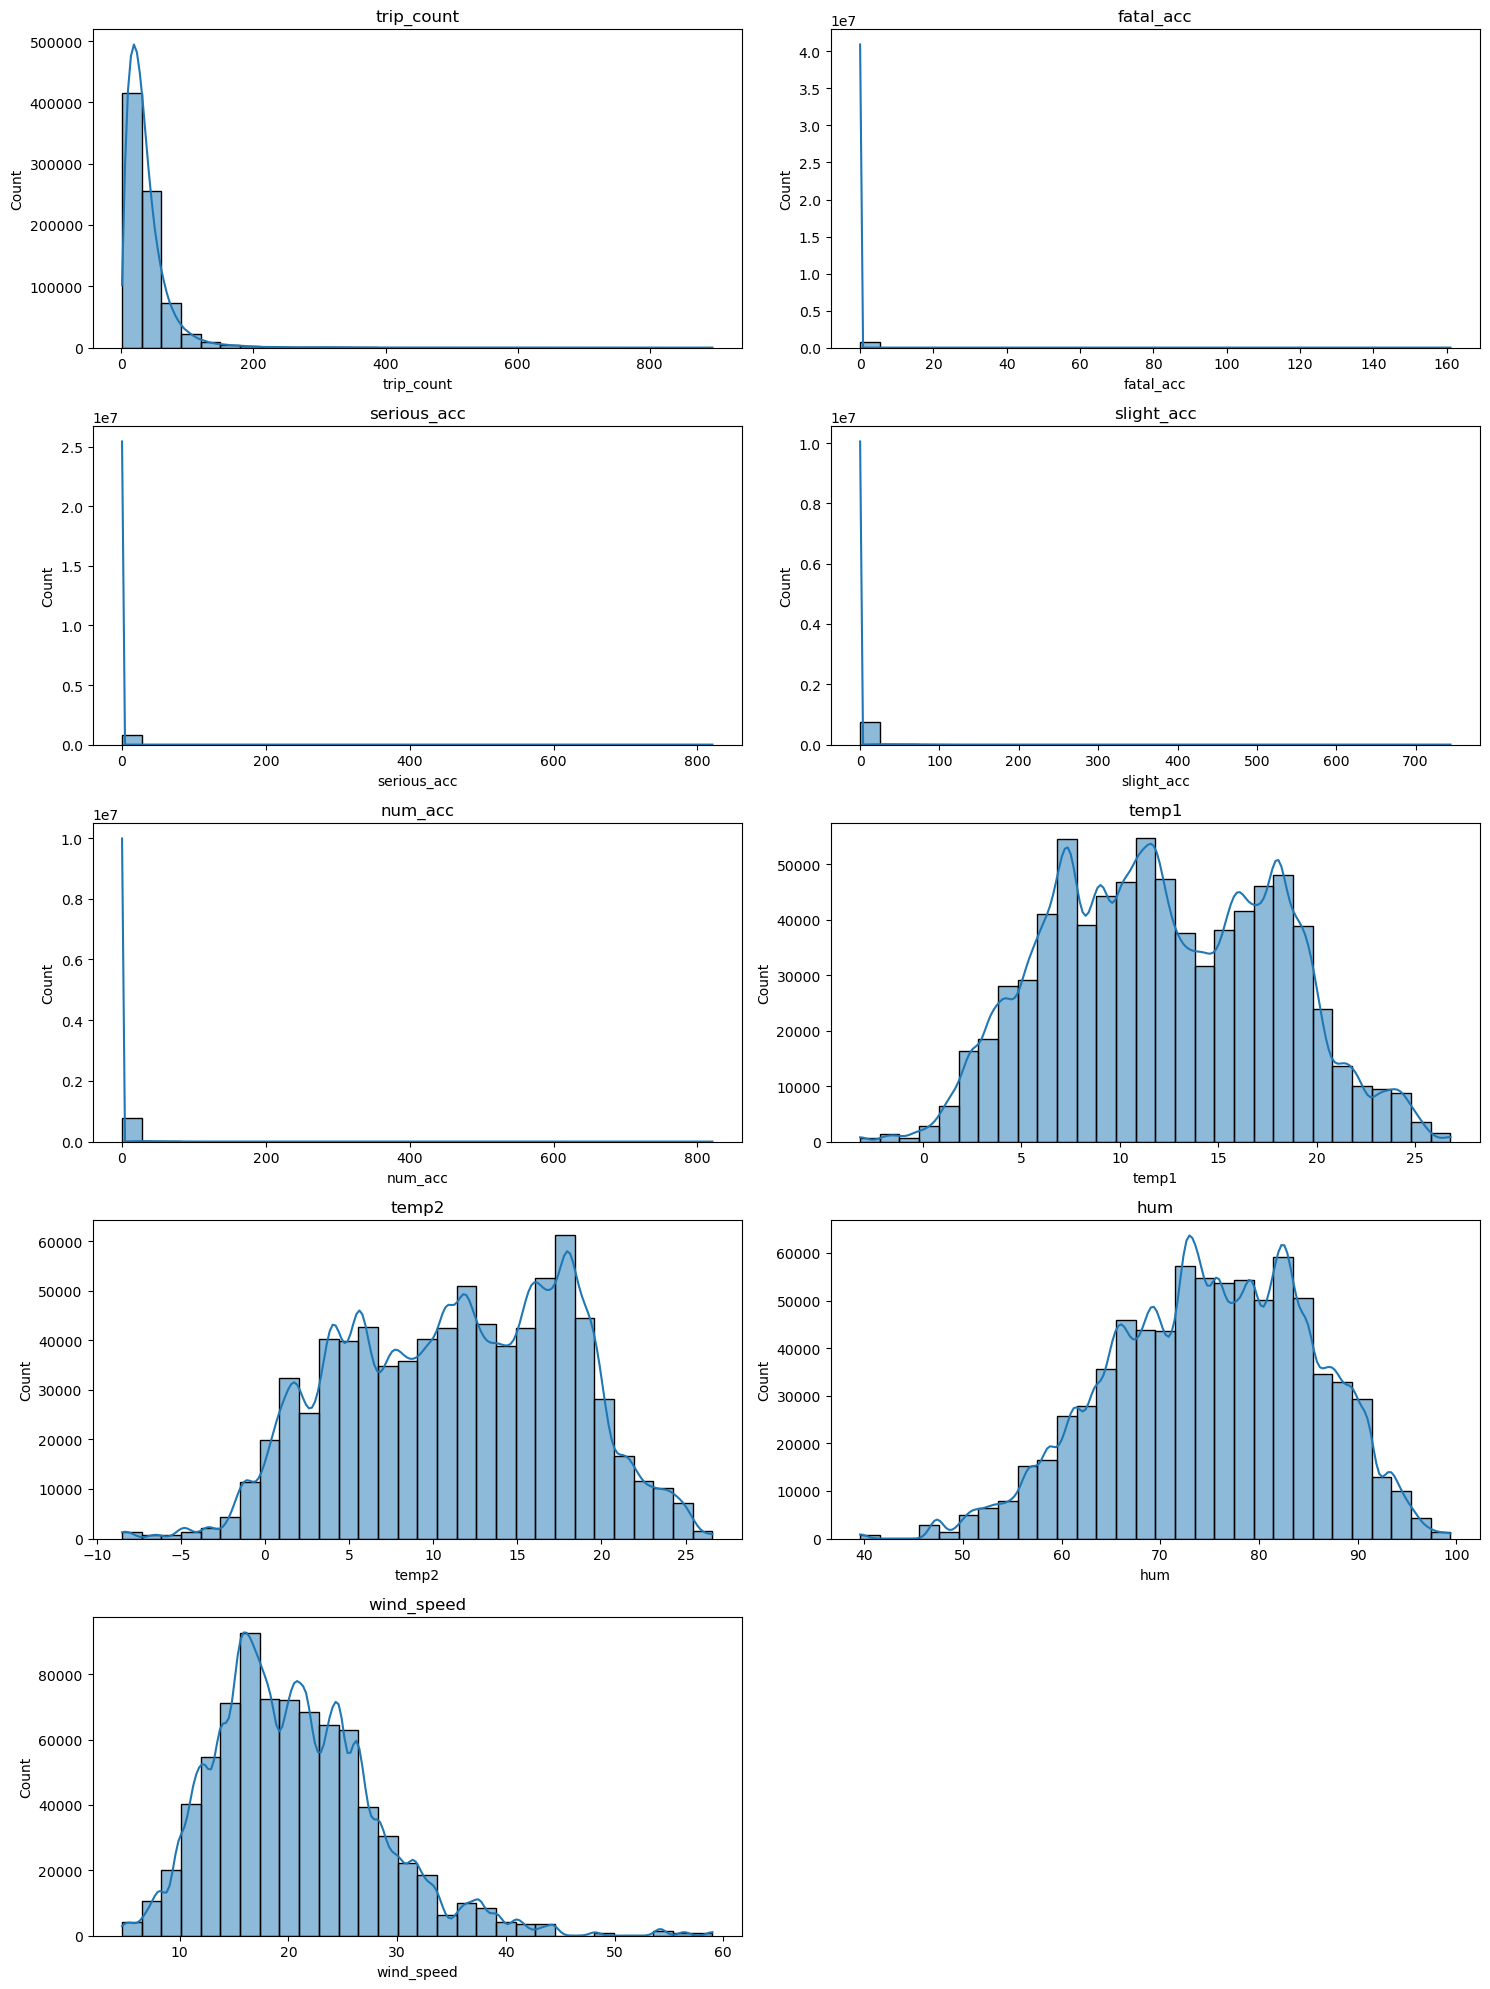

In [17]:
# histogramy dla zmiennych numerycznych
n_cols = 2
n_rows = int(np.ceil(len(numerical_features)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20),sharey=False)
col_idx = 0

for row in range(n_rows):
    for col in range(n_cols):
        if col_idx < len(numerical_features):
            sns.histplot(df[numerical_features[col_idx]], ax = axes[row, col], bins=30, kde=True)
            axes[row, col].set_title(numerical_features[col_idx])
            col_idx += 1
        else:
            break

if n_cols * n_rows >  len(numerical_features):
    for ax in axes.flatten()[len(numerical_features):]:
        ax.remove()
plt.tight_layout()
plt.show()

### 3.2 Zmienne kategoryczne

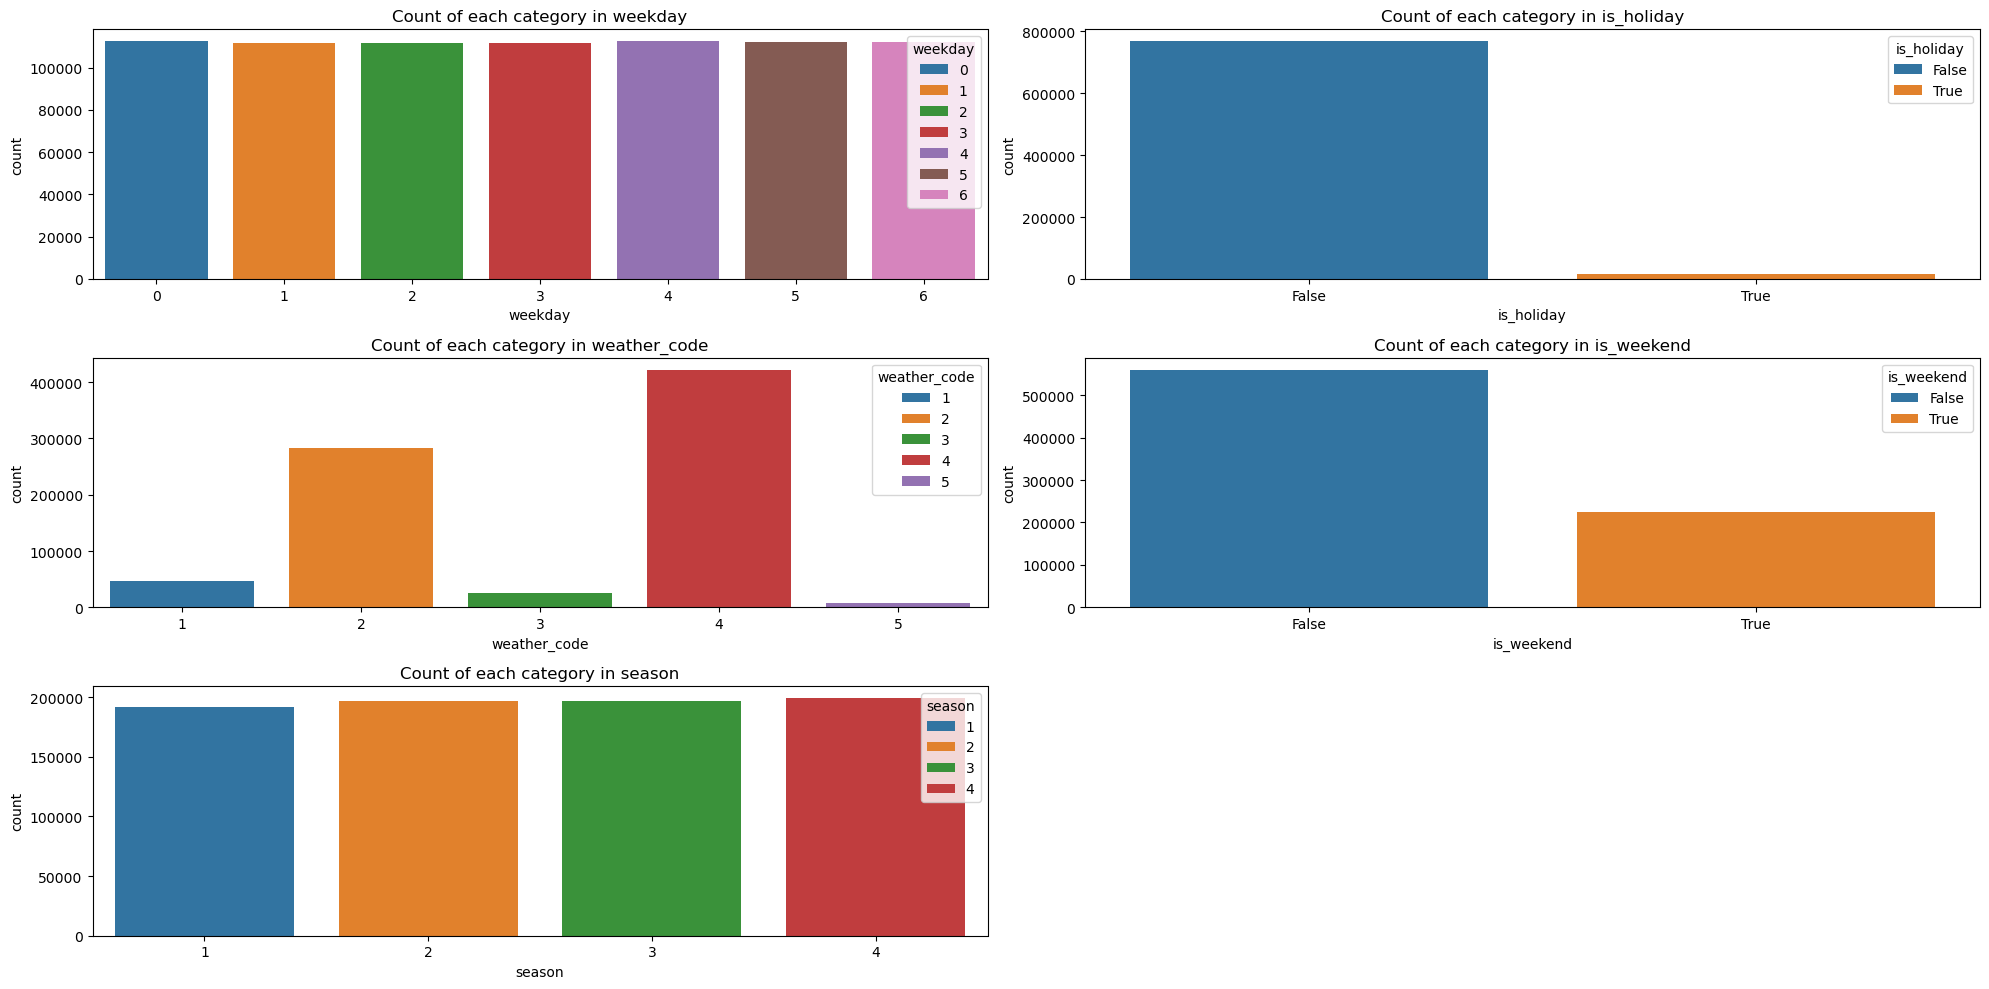

In [18]:
# Wykresy dla zmiennych katgorycznych
n_cols = 2
n_rows=int(np.ceil(len(categorical_features)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10),sharey=False)
col_idx = 0
for row in range(n_rows):
    for col in range(n_cols):
        sns.countplot(ax=axes[row, col], x=categorical_features[col_idx], data=df, hue=categorical_features[col_idx], palette='tab10')
        axes[row, col].set_title(f'Count of each category in {categorical_features[col_idx]}')
        col_idx += 1
        if col_idx >= len(categorical_features):
            break

if n_cols*n_rows >  len(categorical_features):
    for ax in axes.flatten()[len(categorical_features):]:
        ax.remove()
plt.tight_layout()
plt.show()

### 3.3 Graficzna analiza liczby wypożyczń

<Axes: xlabel='weekday', ylabel='trip_count'>

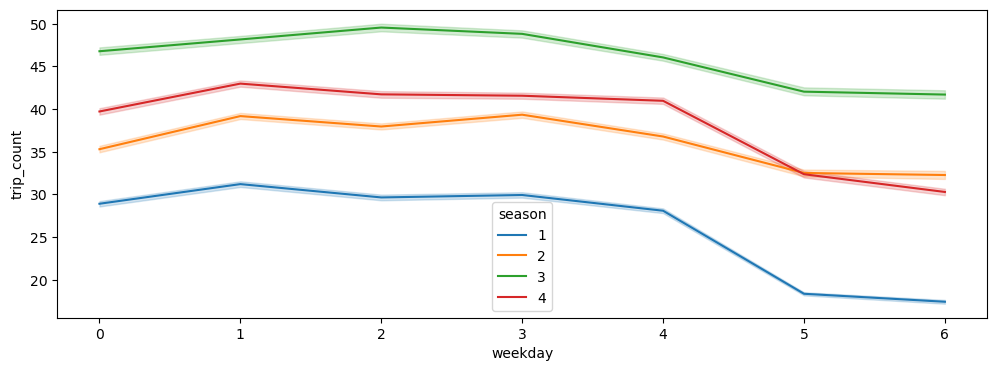

In [19]:
# Wykres liniowy liczby wypożyczeń w zależności od dnia tygodnia i pory roku
plt.figure(figsize=(12,4))
sns.lineplot(x='weekday', y='trip_count', data=df, hue='season', palette='tab10')

<Axes: xlabel='weekday', ylabel='trip_count'>

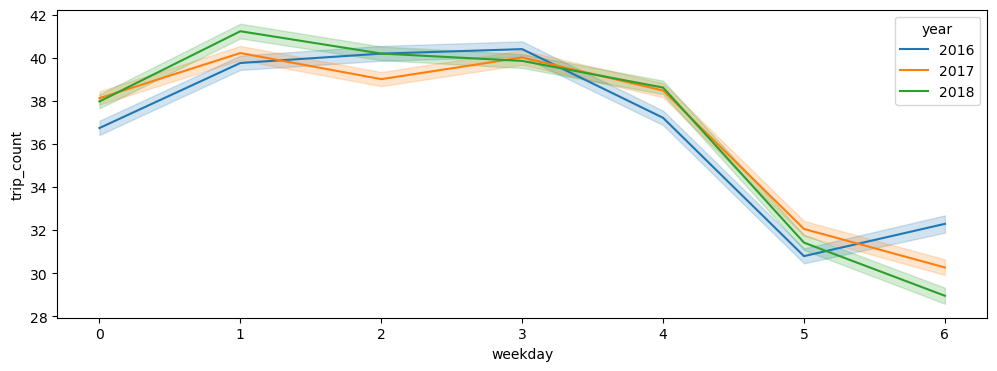

In [20]:
# Wykres liniowy liczby wypożyczeń w zależności od dnia tygodnia i roku
plt.figure(figsize=(12,4))
sns.lineplot(x='weekday', y='trip_count', data=df, hue='year', palette='tab10')

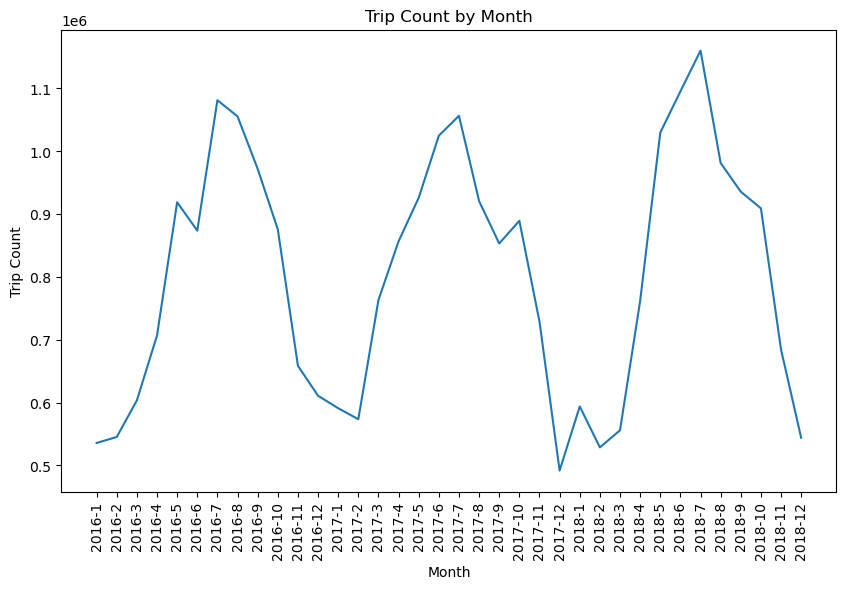

In [21]:
# Wykres liniowy wypożyczeń przez cały zakres czasowy
df_by_m = df.groupby(['year', 'month']).agg({'trip_count': 'sum'}).reset_index()
df_by_m['year_month'] = df_by_m['year'].astype(str) + '-' + df_by_m['month'].astype(str)

plt.figure(figsize=(10,6))
sns.lineplot(x='year_month', y='trip_count', data=df_by_m)
plt.title('Trip Count by Month')
plt.xlabel('Month')
plt.ylabel('Trip Count')
plt.xticks(rotation=90)
plt.show()

### 3.4 Korelacje

In [22]:
# Tabela korelacji dla zmiennych numerycznych
correlation_matrix = df[numerical_features].corr()
correlation_matrix

,trip_count,fatal_acc,serious_acc,slight_acc,num_acc,temp1,temp2,hum,wind_speed
trip_count,1.000000,0.007936,0.078564,0.161815,0.178983,0.252541,0.253967,-0.208687,-0.071897
fatal_acc,0.007936,1.000000,-0.000564,0.008118,0.057035,0.006078,0.006205,0.000677,-0.004039
serious_acc,0.078564,-0.000564,1.000000,0.013866,0.419283,0.017668,0.017601,-0.017219,-0.006353
slight_acc,0.161815,0.008118,0.013866,1.000000,0.912210,0.041199,0.041200,-0.042514,-0.005983
num_acc,0.178983,0.057035,0.419283,0.912210,1.000000,0.044822,0.044802,-0.045495,-0.008207
temp1,0.252541,0.006078,0.017668,0.041199,0.044822,1.000000,0.993104,-0.445837,-0.051726
temp2,0.253967,0.006205,0.017601,0.041200,0.044802,0.993104,1.000000,-0.415808,-0.094227
hum,-0.208687,0.000677,-0.017219,-0.042514,-0.045495,-0.445837,-0.415808,1.000000,-0.029452
wind_speed,-0.071897,-0.004039,-0.006353,-0.005983,-0.008207,-0.051726,-0.094227,-0.029452,1.000000


<Axes: >

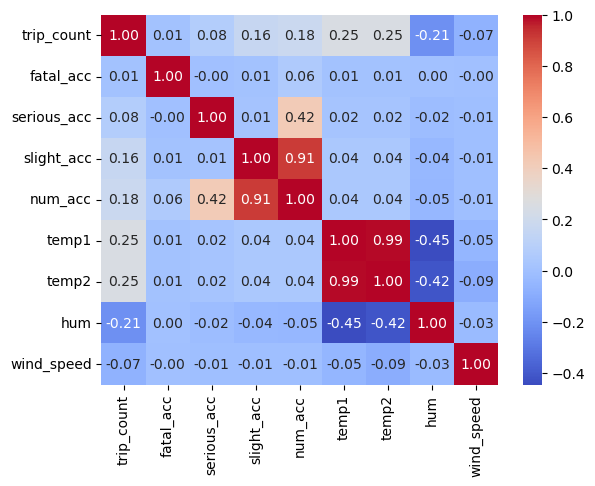

In [23]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

## 4. Budowa modelu regresyjnego lasu losowego

### 4.1 Przygotowanie danych

In [24]:
# Załadowanie potrzebnych bibliotek
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [25]:
# Posortoowanie zbioru danych według daty
df.sort_values(by=['date', 'station_id'], inplace=True)

# Kolumna 'station_name' i 'weather_type' nie będą potrzebna do trenowania modelu
df1 = df.drop(columns=['station_name', 'weather_type', 'date', 'datet'])  

# Oddzielenie zmiennych objaśniających od zmiennej celu
X = df1.drop('trip_count', axis=1)
y = df1['trip_count']

### 4.2 Podział zbioru na zbiory treningowe i testowe

In [26]:
# Chronologiczny podział danych na zbiory treningowe i testowe
split_index=int(len(X)*0.8) #80% danych do treningu
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Ustawienie TimeSeriesSplit dla walidacji krzyżowej
tscv = TimeSeriesSplit(n_splits=4)

### 4.2 Wytrenowanie pierwszego modelu lasu losowego

In [27]:
# Wytrenowanie pierwszego modelu Random Forest
rfr1 = RandomForestRegressor(n_estimators=5, max_depth=2)
rfr1.fit(X_train, y_train)

# Wstępna ewaluacja pierwszego modelu na zbiorze treningowym
rfr1.score(X_train, y_train)

0.10451302355654668

In [28]:
# Wytrenowanie pierwszego modelu
y_pred_rfr1 = rfr1.predict(X_test)

# Ewaluacja modelu
mse_rfr1 = mean_squared_error(y_test, y_pred_rfr1)
rmse_rfr1 = np.sqrt(mse_rfr1)
mae_rfr1 = mean_absolute_error(y_test, y_pred_rfr1)
r2_rfr1 = r2_score(y_test, y_pred_rfr1)

print('Initial Model Test Metrics:')
print(f'Mean Squared Error on test set: {mse_rfr1}')
print(f'Root Mean Squared Error on test set: {rmse_rfr1}')
print(f'Mean Absolute Error on test set: {mae_rfr1}')
print(f'R^2 Score on test set: {r2_rfr1}')

Initial Model Test Metrics:
Mean Squared Error on test set: 1162.2750197852336
Root Mean Squared Error on test set: 34.092154812877894
Mean Absolute Error on test set: 21.26102491794154
R^2 Score on test set: 0.09491437700655336


Bardzo słabe wyniki dla wstępnego modelu. Pierwszym krokiem do poprawy modelu będą lagged features

## 5. Lagging w celu poprawienia modelu

### 5.1 Przygotowanie danych

In [29]:
#posortowanie danych
df2 = df.sort_values(by= ['station_id', 'date'])
df2.head()

,date,station_id,station_name,is_holiday,trip_count,fatal_acc,serious_acc,slight_acc,num_acc,temp1,...,wind_speed,weather_type,weather_code,datet,year,month,day,weekday,is_weekend,season
1,2016-01-01,1.0,"River Street , Clerkenwell",True,7,0,0,0,0,5.9,...,24.7,rain,4,2016-01-01,2016,1,1,4,False,1
640,2016-01-02,1.0,"River Street , Clerkenwell",False,8,0,0,0,0,10.0,...,26.4,rain,4,2016-01-02,2016,1,2,5,True,1
1296,2016-01-03,1.0,"River Street , Clerkenwell",False,8,0,0,0,0,8.0,...,29.5,rain,4,2016-01-03,2016,1,3,6,True,1
1943,2016-01-04,1.0,"River Street , Clerkenwell",False,18,0,0,0,0,8.0,...,19.6,rain,4,2016-01-04,2016,1,4,0,False,1
2617,2016-01-05,1.0,"River Street , Clerkenwell",False,23,0,0,0,0,8.4,...,17.0,rain,4,2016-01-05,2016,1,5,1,False,1


In [30]:
# Stworzenie nowych kolumn z lagowanymi wartościami liczby przejazdów - 1, 7, 30 i 90 dni wstecz
for i in [1, 7, 30, 90]:
    df2[f'lagged_trip_count_{i}d'] = df2.groupby('station_id')['trip_count'].shift(i)

### 5.2 Sprawdzenie poprawności danych po laggingu

In [31]:
# Sprawdzenie pierwszych 10 wierszy zbioru dannych dla stacji o id 50 dla potwierdzenia, żę lagowanie działa poprawnie
df2[df2.station_id == 50].head(10)

,date,station_id,station_name,is_holiday,trip_count,fatal_acc,serious_acc,slight_acc,num_acc,temp1,...,year,month,day,weekday,is_weekend,season,lagged_trip_count_1d,lagged_trip_count_7d,lagged_trip_count_30d,lagged_trip_count_90d
38,2016-01-01,50.0,"East Road, Hoxton",True,9,0,0,0,0,5.9,...,2016,1,1,4,False,1,NaN,NaN,NaN,NaN
679,2016-01-02,50.0,"East Road, Hoxton",False,9,0,0,0,0,10.0,...,2016,1,2,5,True,1,9.0,NaN,NaN,NaN
1335,2016-01-03,50.0,"East Road, Hoxton",False,4,0,0,0,0,8.0,...,2016,1,3,6,True,1,9.0,NaN,NaN,NaN
1982,2016-01-04,50.0,"East Road, Hoxton",False,32,0,0,0,0,8.0,...,2016,1,4,0,False,1,4.0,NaN,NaN,NaN
2656,2016-01-05,50.0,"East Road, Hoxton",False,38,0,0,0,0,8.4,...,2016,1,5,1,False,1,32.0,NaN,NaN,NaN
3331,2016-01-06,50.0,"East Road, Hoxton",False,38,0,0,0,0,7.0,...,2016,1,6,2,False,1,38.0,NaN,NaN,NaN
4004,2016-01-07,50.0,"East Road, Hoxton",False,32,0,0,0,0,7.5,...,2016,1,7,3,False,1,38.0,NaN,NaN,NaN
4678,2016-01-08,50.0,"East Road, Hoxton",False,29,0,0,0,0,6.1,...,2016,1,8,4,False,1,32.0,9.0,NaN,NaN
5353,2016-01-09,50.0,"East Road, Hoxton",False,15,0,0,0,0,9.0,...,2016,1,9,5,True,1,29.0,9.0,NaN,NaN
6029,2016-01-10,50.0,"East Road, Hoxton",False,11,0,0,0,0,6.7,...,2016,1,10,6,True,1,15.0,4.0,NaN,NaN


In [32]:
# Uzupełnienie brakujących wartości w nowych kolumnach
df2.fillna(0, inplace=True)
df2.head(10)

,date,station_id,station_name,is_holiday,trip_count,fatal_acc,serious_acc,slight_acc,num_acc,temp1,...,year,month,day,weekday,is_weekend,season,lagged_trip_count_1d,lagged_trip_count_7d,lagged_trip_count_30d,lagged_trip_count_90d
1,2016-01-01,1.0,"River Street , Clerkenwell",True,7,0,0,0,0,5.9,...,2016,1,1,4,False,1,0.0,0.0,0.0,0.0
640,2016-01-02,1.0,"River Street , Clerkenwell",False,8,0,0,0,0,10.0,...,2016,1,2,5,True,1,7.0,0.0,0.0,0.0
1296,2016-01-03,1.0,"River Street , Clerkenwell",False,8,0,0,0,0,8.0,...,2016,1,3,6,True,1,8.0,0.0,0.0,0.0
1943,2016-01-04,1.0,"River Street , Clerkenwell",False,18,0,0,0,0,8.0,...,2016,1,4,0,False,1,8.0,0.0,0.0,0.0
2617,2016-01-05,1.0,"River Street , Clerkenwell",False,23,0,0,0,0,8.4,...,2016,1,5,1,False,1,18.0,0.0,0.0,0.0
3292,2016-01-06,1.0,"River Street , Clerkenwell",False,28,0,0,0,0,7.0,...,2016,1,6,2,False,1,23.0,0.0,0.0,0.0
3965,2016-01-07,1.0,"River Street , Clerkenwell",False,20,0,0,0,0,7.5,...,2016,1,7,3,False,1,28.0,0.0,0.0,0.0
4639,2016-01-08,1.0,"River Street , Clerkenwell",False,18,0,0,0,0,6.1,...,2016,1,8,4,False,1,20.0,7.0,0.0,0.0
5314,2016-01-09,1.0,"River Street , Clerkenwell",False,24,0,0,0,0,9.0,...,2016,1,9,5,True,1,18.0,8.0,0.0,0.0
5990,2016-01-10,1.0,"River Street , Clerkenwell",False,19,0,0,0,0,6.7,...,2016,1,10,6,True,1,24.0,8.0,0.0,0.0


In [33]:
# Posortoowanie zbioru danych według daty
df2.sort_values(by=['date', 'station_id'], inplace=True)

## 6. Budowa modelu lasu losowego z lagged features

In [34]:
# Wczytanie potrzebnych bibliotek
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### 5.1 Przygotowanie danych

In [35]:
# Kolumny 'station_name', 'weather_type', 'date' oraz 'datet' nie będą potrzebna do trenowania modelu
df2 = df2.drop(columns=['station_name', 'weather_type', 'date', 'datet'])  

# Oddzielenie zmiennych objaśniających od zmiennej celu
X = df2.drop('trip_count', axis=1)
y = df2['trip_count']

### 6.2 Podział zbioru na zbiory treniningowye i testowe

In [36]:
# Chronologiczny podział danych na zbiory treningowe i testowe
split_index=int(len(X)*0.8) #80% danych do treningu
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Ustawienie TimeSeriesSplit dla walidacji krzyżowej
tscv = TimeSeriesSplit(n_splits=4)

### 6.3 Wytrenowanie drugiego modelu lasu losowego

In [37]:
# Wytrenowanie drugiego modelu RandomForest
rfr2 = RandomForestRegressor(n_estimators=5, max_depth=2)
rfr2.fit(X_train, y_train)

# Wstępna ewaluacja drugiego modelu ma zbiorze treningowym
rfr2.score(X_train, y_train)

0.5847241911279919

Znacząca poprawa r2 względem danych bez laggowania

### 6.4 Ewaluacja modelu lasu losowego

In [38]:
y_pred_rfr2 = rfr2.predict(X_test)

# Ewaluacja modelu
mse_rfr2 = mean_squared_error(y_test, y_pred_rfr2)
rmse_rfr2 = np.sqrt(mse_rfr2)
mae_rfr2 = mean_absolute_error(y_test, y_pred_rfr2)
r2_rfr2 = r2_score(y_test, y_pred_rfr2)


print(f'Mean Squared Error on test set: {mse_rfr2}')
print(f'Root Mean Squared Error on test set: {rmse_rfr2}')
print(f'Mean Absolute Error on test set: {mae_rfr2}')
print(f'R^2 Score on test set: {r2_rfr2}')

Mean Squared Error on test set: 499.4364024613248
Root Mean Squared Error on test set: 22.348073797563064
Mean Absolute Error on test set: 13.915402006565227
R^2 Score on test set: 0.6110793919060216


### 6.5 Optymalizacja hiperparametrów

In [39]:
# Ustawienie parametrów do grid search
param_grid = {
    'n_estimators': [5, 10, 20],
    'max_depth': [2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Ustawienie GridSeatchCV
rfr2_cv = GridSearchCV(estimator=rfr2, param_grid=param_grid, cv=tscv)

# Trenowanie grid search na zbiorze treningowym
rfr2_cv.fit(X_train, y_train)
# Pozyskanie najlepszego modelu i najlepszych hiperparametrów
best_model_rfr2_cv = rfr2_cv.best_estimator_
best_params_rfr2_cv = rfr2_cv.best_params_

# Ewaluacja najlepszego modelu na zbiorze testowym
y_pred_rfr2_cv = best_model_rfr2_cv.predict(X_test)
mse_rfr2_cv = mean_squared_error(y_test, y_pred_rfr2_cv)
rmse_rfr2_cv = np.sqrt(mse_rfr2_cv)
mae_rfr2_cv = mean_absolute_error(y_test, y_pred_rfr2_cv)
r2_rfr2_cv = r2_score(y_test, y_pred_rfr2_cv)

print(f'Best parameters: {best_params_rfr2_cv}')
print(f'Mean Squared Error on test set: {mse_rfr2_cv}')
print(f'Root Mean Squared Error on test set: {rmse_rfr2_cv}')
print(f'Mean Absolute Error on test set: {mae_rfr2_cv}')
print(f'R^2 Score on test set: {r2_rfr2_cv}')

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 20}
Mean Squared Error on test set: 245.009472651073
Root Mean Squared Error on test set: 15.65277843231268
Mean Absolute Error on test set: 9.56328455048335
R^2 Score on test set: 0.8092064722902947


## 7. Budowa modelu XGBoost

In [40]:
# Załadowanie potrzebnych bibliotek
from xgboost import XGBRegressor

### 7.1 Wytrenowanie modelu XGBoost

Korzystamy z danych przygotowanych w ten sam sposób co dla modelu lasu losowego

In [41]:
# Wytrenowanie pierwszego modelu
xgbr = XGBRegressor(random_state=42)
xgbr.fit(X_train, y_train)

# Wstępna ewaluacja drugiego modelu ma zbiorze treningowym
xgbr.score(X_train, y_train)

0.8889618515968323

### 7.2 Ewaluacja modelu XGBoost

In [42]:
y_pred_xgbr = xgbr.predict(X_test)

# Ewaluacja modelu
mse_xgbr = mean_squared_error(y_test, y_pred_xgbr)
rmse_xgbr = np.sqrt(mse_xgbr)
mae_xgbr = mean_absolute_error(y_test, y_pred_xgbr)
r2_xgbr = r2_score(y_test, y_pred_xgbr)


print(f'Mean Squared Error on test set: {mse_xgbr}')
print(f'Root Mean Squared Error on test set: {rmse_xgbr}')
print(f'Mean Absolute Error on test set: {mae_xgbr}')
print(f'R^2 Score on test set: {r2_xgbr}')

Mean Squared Error on test set: 256.47988872323305
Root Mean Squared Error on test set: 16.01498950119022
Mean Absolute Error on test set: 9.662075680337844
R^2 Score on test set: 0.8002742528915405


### 7.3 Optymalizacja hiperparametrów

In [43]:
# Ustawienie parametrów do grid search
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Ustawienie GridSeatchCV
xgbr_cv = GridSearchCV(estimator=xgbr, param_grid=param_grid, cv=tscv)

# Trenowanie grid search na zbiorze treningowym
xgbr_cv.fit(X_train, y_train)

# Pozyskanie najlepszego modelu i najlepszych hiperparametrów
best_model_xgbr_cv = xgbr_cv.best_estimator_
best_params_xgbr_cv = xgbr_cv.best_params_

# Ewaluacja najlepszego modelu na zbiorze testowym
y_pred_xgbr_cv = best_model_xgbr_cv.predict(X_test)
mse_xgbr_cv = mean_squared_error(y_test, y_pred_xgbr_cv)
rmse_xgbr_cv = np.sqrt(mse_xgbr_cv)
mae_xgbr_cv = mean_absolute_error(y_test, y_pred_xgbr_cv)
r2_xgbr_cv = r2_score(y_test, y_pred_xgbr_cv)

print(f'Best parameters: {best_params_xgbr_cv}')
print(f'Mean Squared Error on test set: {mse_xgbr_cv}')
print(f'Root Mean Squared Error on test set: {rmse_xgbr_cv}')
print(f'Mean Absolute Error on test set: {mae_xgbr_cv}')
print(f'R^2 Score on test set: {r2_xgbr_cv}')

Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}
Mean Squared Error on test set: 232.86278044967426
Root Mean Squared Error on test set: 15.259842084689941
Mean Absolute Error on test set: 9.21048250614383
R^2 Score on test set: 0.8186653852462769


## 8. Porównanie modeli

### 8.1 Wyniki ewaluacji obu modeli w formie tabelarycznej

In [44]:
# Stworzenie tabeli z wynikami dla obu modeli
results_df = pd.DataFrame(
    {
    'metric': ['MSE', 'RMSE', 'MAE', 'R2'],
    'Random Forest': [mse_rfr2_cv, rmse_rfr2_cv, mae_rfr2_cv, r2_rfr2_cv],
    'XGBoost': [mse_xgbr_cv, rmse_xgbr_cv, mae_xgbr_cv, r2_xgbr_cv]
    }
)

results_df

,metric,Random Forest,XGBoost
0,MSE,245.009473,232.862780
1,RMSE,15.652778,15.259842
2,MAE,9.563285,9.210483
3,R2,0.809206,0.818665


In [45]:
# Przekształcenie tabeli z wynikami do formatu długiego
result_df_long = results_df.melt(id_vars='metric', var_name='model', value_name='value')

result_df_long.head()

,metric,model,value
0,MSE,Random Forest,245.009473
1,RMSE,Random Forest,15.652778
2,MAE,Random Forest,9.563285
3,R2,Random Forest,0.809206
4,MSE,XGBoost,232.862780


### 8.2 Wyniki ewaluacji modeli w formie wykresów

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 1200x800 with 0 Axes>

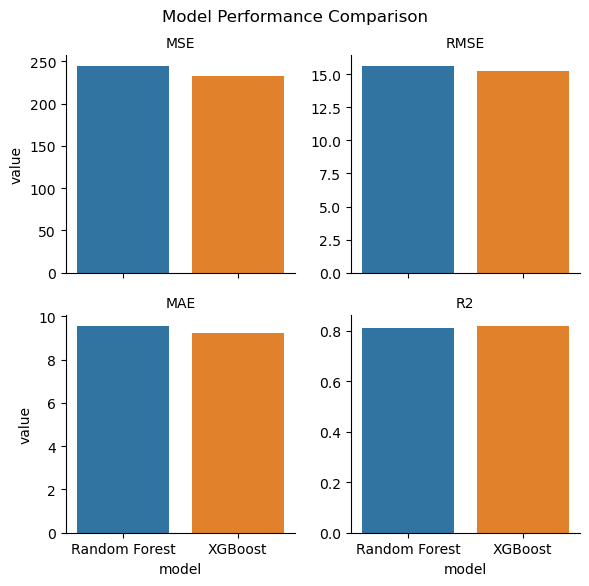

In [46]:
# Wykres z wynikami dla obu modeli
plt.figure(figsize=(12,8))
grid = sns.FacetGrid(result_df_long, col='metric', hue='model', sharey=False, col_wrap = 2)
grid.map(sns.barplot, 'model', 'value')
grid.set_titles(col_template='{col_name}')
grid.fig.suptitle('Model Performance Comparison', y=0.97, fontsize=12)
plt.tight_layout()

### 8.3 Porównananie ważności cech

In [47]:
# Stworzenie tabeli z istonościami zmiennych dla obu modeli
importance_df = pd.DataFrame(
    {
        'feature': X_train.columns,
        'Random Forest': best_model_rfr2_cv.feature_importances_,
        'XGBoost': best_model_xgbr_cv.feature_importances_
    }
    
)
# Przekształcenie tabeli do formatu długiego
importance_df = importance_df.melt(id_vars='feature', var_name='model', value_name='importance')

importance_df.head()

,feature,model,importance
0,station_id,Random Forest,0.003820
1,is_holiday,Random Forest,0.004562
2,fatal_acc,Random Forest,0.000000
3,serious_acc,Random Forest,0.000002
4,slight_acc,Random Forest,0.000092


Text(0.5, 1.0, 'Feature Importance Comparison: Random Forest vs XGBoost')

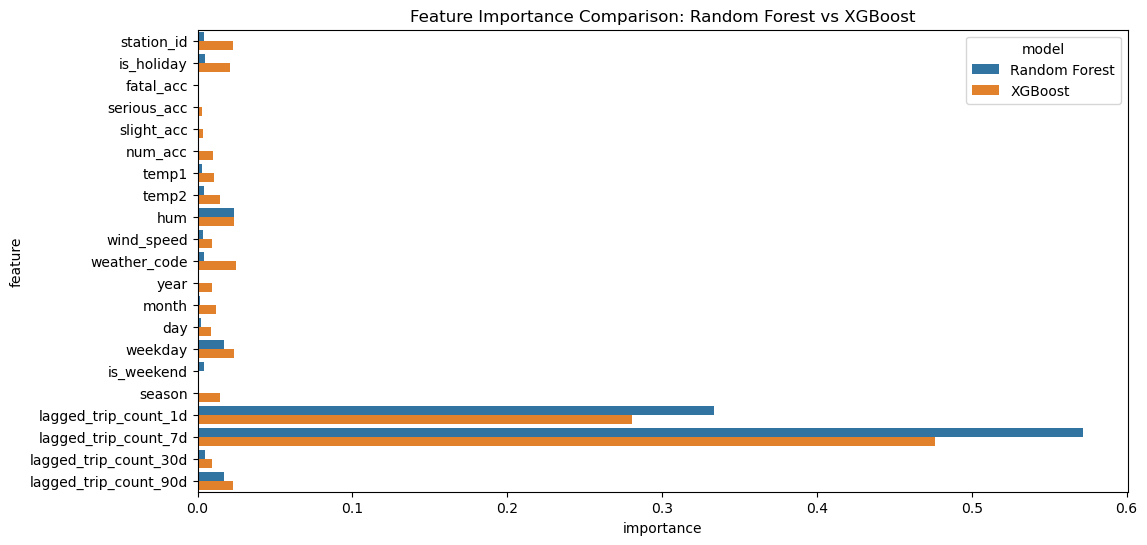

In [48]:
# Wykres ważności cech
plt.figure(figsize=(12,6))
sns.barplot(data=importance_df, x='importance', y='feature', hue='model')
plt.title('Feature Importance Comparison: Random Forest vs XGBoost')

### 8.4 Porównanie dopasowania predykcji obu modeli do danych rzeczywistych

In [50]:
df_pred= X_test.drop(columns=['lagged_trip_count_1d', 'lagged_trip_count_7d', 'lagged_trip_count_30d', 'lagged_trip_count_90d'])
df_pred['date']=pd.to_datetime(df_pred[['year', 'month', 'day']])
df_pred['trip_count'] = y_test
df_pred['trip_count_pred_rfr'] = y_pred_rfr2_cv
df_pred['trip_count_pred_xgbr'] = y_pred_xgbr_cv
df_pred.head()

,station_id,is_holiday,fatal_acc,serious_acc,slight_acc,num_acc,temp1,temp2,hum,wind_speed,...,year,month,day,weekday,is_weekend,season,date,trip_count,trip_count_pred_rfr,trip_count_pred_xgbr
628418,780.0,False,0,0,0,0,16.2,16.2,86.3,12.2,...,2018,5,30,2,False,2,2018-05-30,63,49.955266,49.514240
628419,781.0,False,0,0,0,0,16.2,16.2,86.3,12.2,...,2018,5,30,2,False,2,2018-05-30,25,21.277115,23.947220
628420,782.0,False,0,0,0,0,16.2,16.2,86.3,12.2,...,2018,5,30,2,False,2,2018-05-30,33,44.166844,37.983643
628421,783.0,False,0,0,0,0,16.2,16.2,86.3,12.2,...,2018,5,30,2,False,2,2018-05-30,29,25.342134,25.295099
628422,784.0,False,0,0,0,0,16.2,16.2,86.3,12.2,...,2018,5,30,2,False,2,2018-05-30,18,17.042472,16.372370


In [51]:
df_grouped = df_pred.groupby(['station_id']).agg({'trip_count': 'sum', 'trip_count_pred_rfr': 'sum', 'trip_count_pred_xgbr': 'sum'}).sort_values(by='trip_count', ascending=False).reset_index()
popular_stations = df_grouped['station_id'].loc[0:4]
popular_stations

0    191.0
1    154.0
2    303.0
3    307.0
4    374.0
Name: station_id, dtype: float64

In [52]:
df_plot = df_pred[df['station_id'].isin(popular_stations)]
df_plot

C:\Users\malgo\AppData\Local\Temp\ipykernel_13496\3891700496.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_plot = df_pred[df['station_id'].isin(popular_stations)]


,station_id,is_holiday,fatal_acc,serious_acc,slight_acc,num_acc,temp1,temp2,hum,wind_speed,...,year,month,day,weekday,is_weekend,season,date,trip_count,trip_count_pred_rfr,trip_count_pred_xgbr
628607,154.0,False,0,0,0,0,18.6,18.6,84.6,15.4,...,2018,5,31,3,False,2,2018-05-31,311,336.826468,309.429932
628640,191.0,False,0,0,0,0,18.6,18.6,84.6,15.4,...,2018,5,31,3,False,2,2018-05-31,317,241.063015,180.926178
628739,303.0,False,0,0,0,0,18.6,18.6,84.6,15.4,...,2018,5,31,3,False,2,2018-05-31,213,103.142114,96.576897
628741,307.0,False,0,0,0,0,18.6,18.6,84.6,15.4,...,2018,5,31,3,False,2,2018-05-31,206,166.470345,167.863510
628797,374.0,False,0,0,0,0,18.6,18.6,84.6,15.4,...,2018,5,31,3,False,2,2018-05-31,243,113.004140,105.578461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784344,303.0,False,0,0,0,0,9.2,8.5,93.3,15.4,...,2018,12,30,6,True,1,2018-12-30,108,104.094129,102.805969
784346,307.0,False,0,0,0,0,9.2,8.5,93.3,15.4,...,2018,12,30,6,True,1,2018-12-30,121,59.905802,71.838097
784965,191.0,False,0,0,0,0,8.8,7.1,83.0,14.7,...,2018,12,31,0,False,1,2018-12-31,266,169.126673,153.307770
785062,303.0,False,0,0,0,0,8.8,7.1,83.0,14.7,...,2018,12,31,0,False,1,2018-12-31,142,64.651602,92.273613


Text(0.5, 1.0, 'Actual vs Predicted Trip Count for Station ID 191')

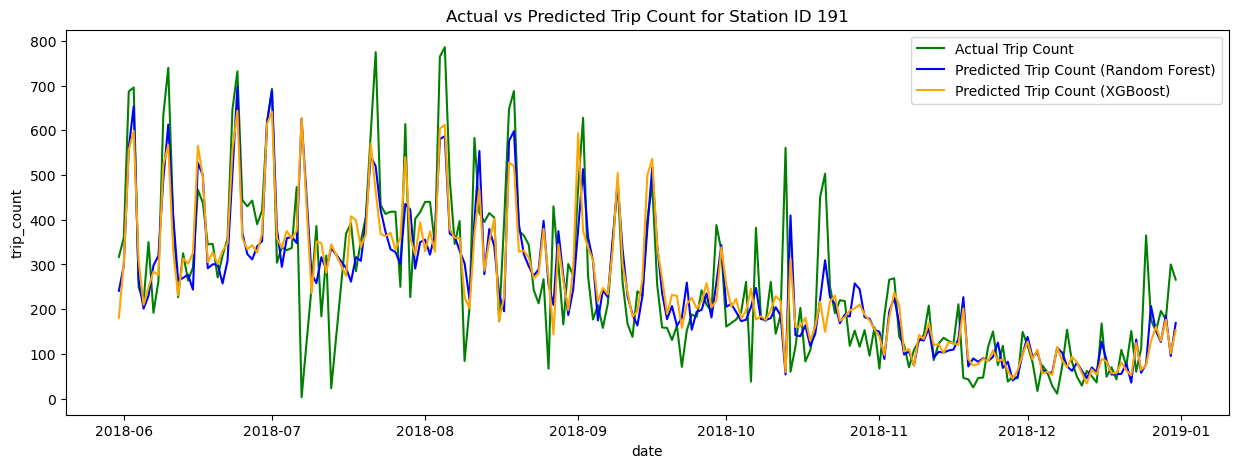

In [53]:
station=popular_stations[0]
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count', label='Actual Trip Count', color='green')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_rfr', label='Predicted Trip Count (Random Forest)', color='blue')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_xgbr', label='Predicted Trip Count (XGBoost)', color='orange')
plt.title(f'Actual vs Predicted Trip Count for Station ID {int(station)}')

Text(0.5, 1.0, 'Actual vs Predicted Trip Count for Station ID 154')

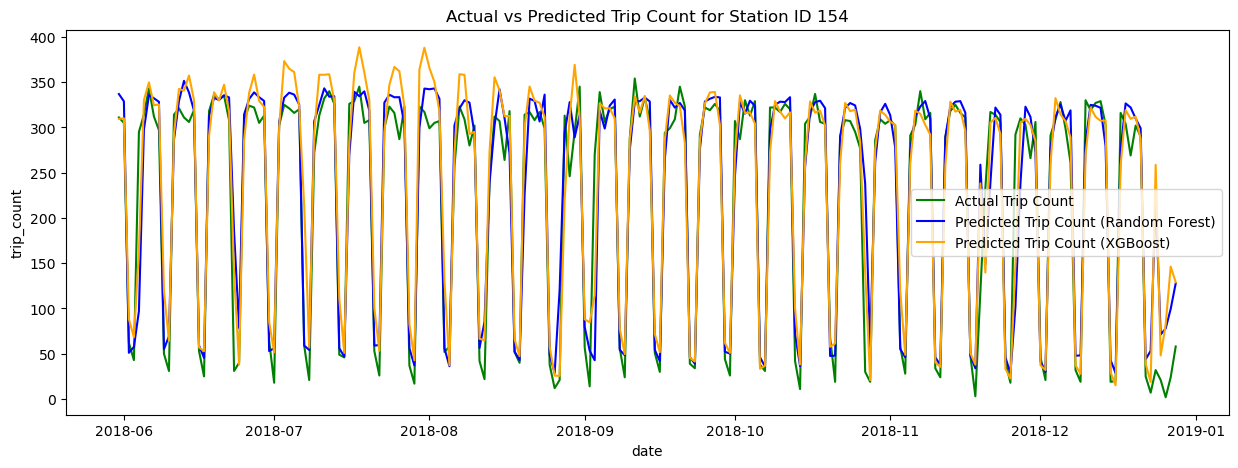

In [54]:
station=popular_stations[1]
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count', label='Actual Trip Count', color='green')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_rfr', label='Predicted Trip Count (Random Forest)', color='blue')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_xgbr', label='Predicted Trip Count (XGBoost)', color='orange')
plt.title(f'Actual vs Predicted Trip Count for Station ID {int(station)}')

Text(0.5, 1.0, 'Actual vs Predicted Trip Count for Station ID 303')

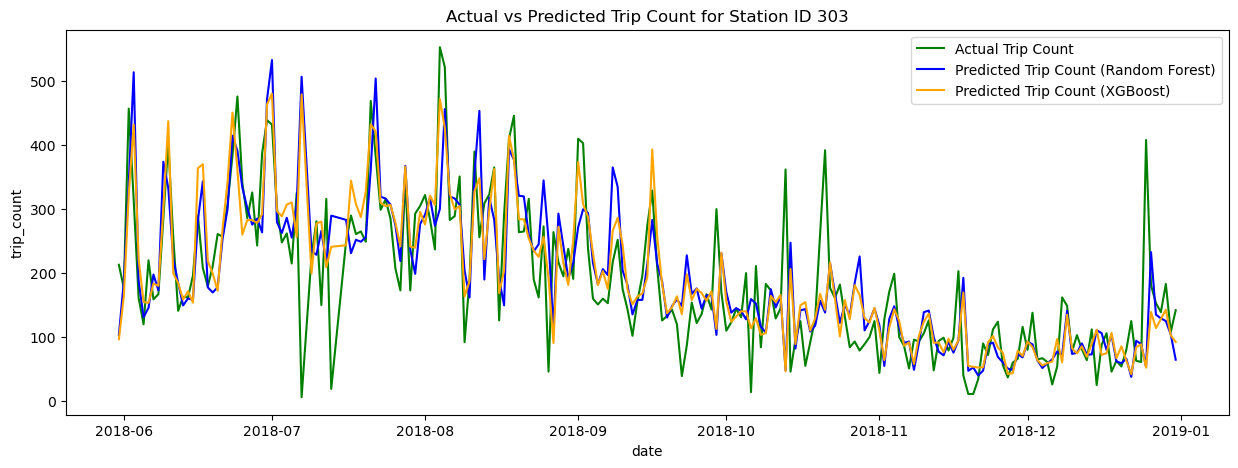

In [55]:
station=popular_stations[2]
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count', label='Actual Trip Count', color='green')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_rfr', label='Predicted Trip Count (Random Forest)', color='blue')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_xgbr', label='Predicted Trip Count (XGBoost)', color='orange')
plt.title(f'Actual vs Predicted Trip Count for Station ID {int(station)}')

Text(0.5, 1.0, 'Actual vs Predicted Trip Count for Station ID 307')

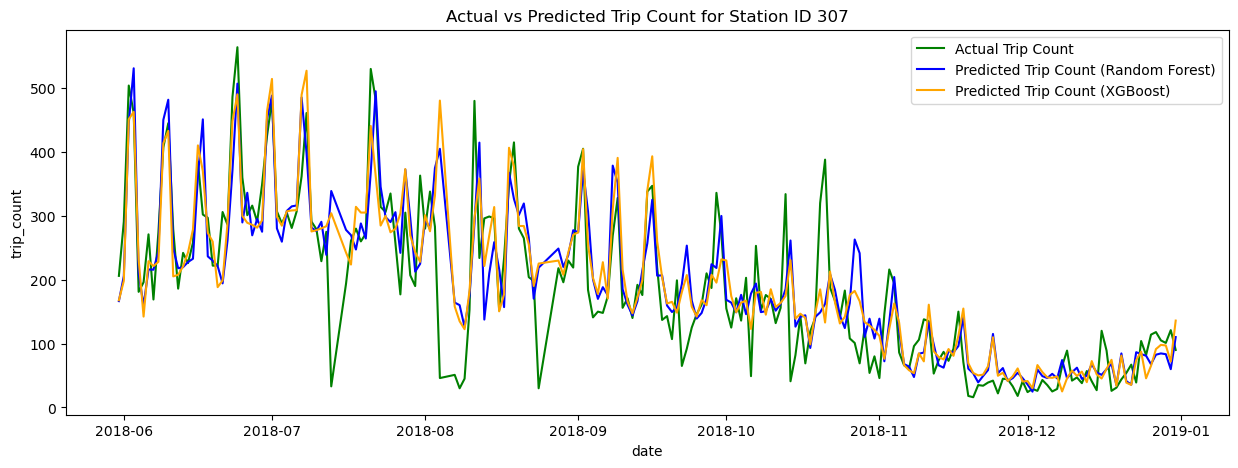

In [56]:
station=popular_stations[3]
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count', label='Actual Trip Count', color='green')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_rfr', label='Predicted Trip Count (Random Forest)', color='blue')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_xgbr', label='Predicted Trip Count (XGBoost)', color='orange')
plt.title(f'Actual vs Predicted Trip Count for Station ID {int(station)}')

Text(0.5, 1.0, 'Actual vs Predicted Trip Count for Station ID 374')

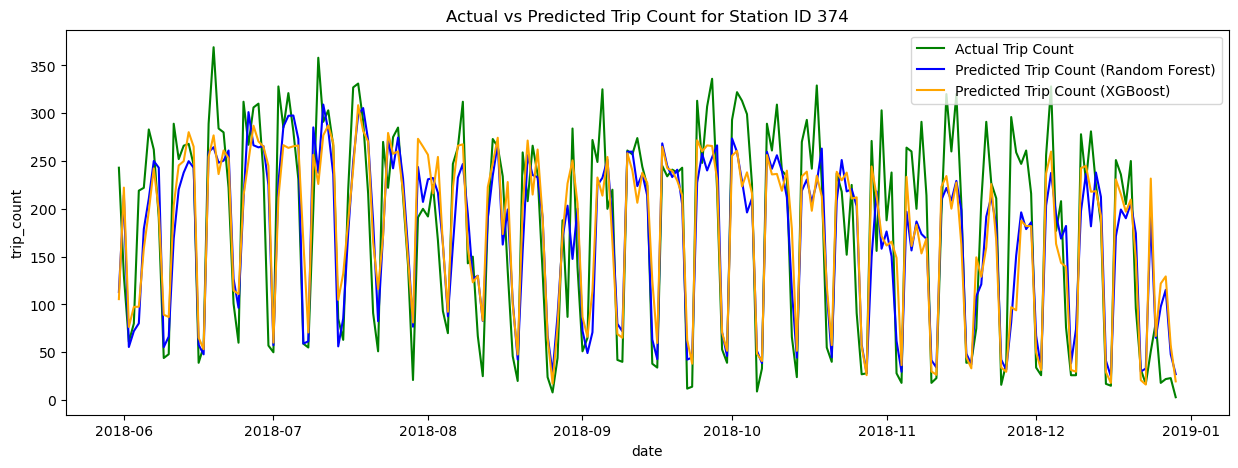

In [57]:
station=popular_stations[4]
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count', label='Actual Trip Count', color='green')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_rfr', label='Predicted Trip Count (Random Forest)', color='blue')
sns.lineplot(data=df_plot[df_plot['station_id']==station], x='date', y='trip_count_pred_xgbr', label='Predicted Trip Count (XGBoost)', color='orange')
plt.title(f'Actual vs Predicted Trip Count for Station ID {int(station)}')